# Retail Customer Intelligence Platform

This notebook develops a business-facing analytics and machine learning workflow on the UCI Online Retail dataset. The objective is to move from raw transaction records to practical decisions around customer segmentation, retention, future customer value, personalization, and demand monitoring.

## Analytical questions
- Which customer groups behave differently enough to warrant distinct lifecycle strategies?
- How does retention evolve by acquisition cohort, and which cohorts generate stronger revenue over time?
- Which customers are most likely to create value over the next 90 days?
- How much lift does a simple personalized recommender provide over a popularity baseline?
- What product-family and seasonality patterns matter most for planning?


## Notebook design

The notebook intentionally uses reusable modules from `src/` rather than embedding all logic inline. That keeps the analytical narrative readable and makes the Streamlit application consume the same prepared data and trained artifacts.

### Data placement
Place the UCI Online Retail file under `data/raw/`. The loader searches recursively for common filenames such as:

- `Online Retail.xlsx`
- `online_retail.xlsx`
- `Online Retail.csv`
- `online_retail.csv`

The platform standardizes that file into a reusable retail schema with orders, products, customers, quantities, revenue, countries, and derived product families.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px

ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.config import DEFAULT_CUSTOMER_SAMPLE_FRAC
from src.models.cohort import build_retention_matrix
from src.models.demand import forecast_category_demand, top_category_shifts
from src.models.future_value import build_snapshot_dataset, choose_target_definition, train_future_value_models
from src.models.recommender import recommend_personalized, recommend_popular, train_recommender
from src.models.segmentation import compare_segmentation_models, fit_segmentation_model
from src.pipeline import prepare_data_assets

plt.style.use("ggplot")
pd.set_option("display.max_columns", 120)


In [2]:
prepared = prepare_data_assets(sample_frac=DEFAULT_CUSTOMER_SAMPLE_FRAC)
transactions = prepared["transactions"]
customer_features = prepared["customer_features"]
cohort_retention = prepared["cohort_retention"]
cohort_revenue = prepared["cohort_revenue"]
monthly_demand = prepared["monthly_demand"]
product_lookup = prepared["product_lookup"]

print(f"Transactions loaded: {len(transactions):,}")
print(f"Customers in feature table: {customer_features['customer_id'].nunique():,}")
print(f"Date range: {transactions['t_dat'].min().date()} to {transactions['t_dat'].max().date()}")


Transactions loaded: 397,884
Customers in feature table: 4,338
Date range: 2010-12-01 to 2011-12-09


## 1. Data quality and retail context

The UCI Online Retail dataset offers invoice-level purchase history with customer identifiers, product descriptions, quantities, unit prices, and country. It does not include marketing exposure, customer demographics, product hierarchy, or inventory state, so this project focuses on behavioral and transaction-derived intelligence rather than causal attribution.


In [3]:
quality_summary = pd.DataFrame(
    {
        "rows": [len(transactions), len(customer_features), len(product_lookup)],
        "columns": [transactions.shape[1], customer_features.shape[1], product_lookup.shape[1]],
    },
    index=["transactions", "customer_features", "product_lookup"],
)
quality_summary


,rows,columns
transactions,397884,17
customer_features,4338,27
product_lookup,3665,3


In [4]:
missingness = (
    transactions[["product_name", "product_family", "country", "unit_price", "quantity", "revenue"]]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_share")
    .to_frame()
)
missingness


,missing_share
product_name,0.0
product_family,0.0
country,0.0
unit_price,0.0
quantity,0.0
revenue,0.0


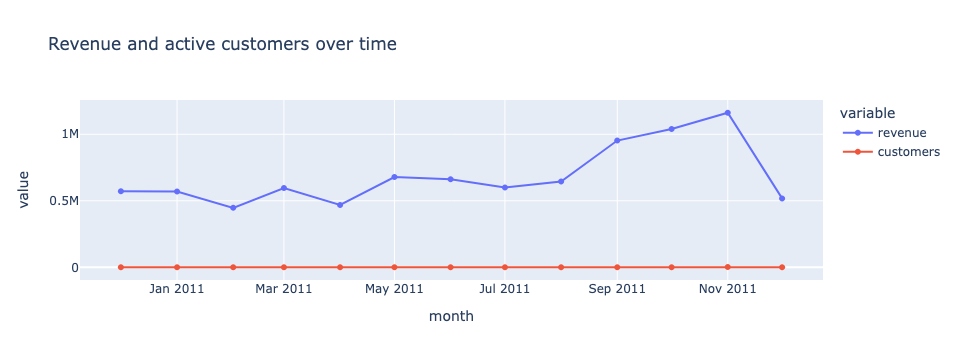

In [5]:
monthly_overview = (
    transactions.groupby("month")
    .agg(revenue=("revenue", "sum"), customers=("customer_id", "nunique"), units=("quantity", "sum"))
    .reset_index()
)
px.line(monthly_overview, x="month", y=["revenue", "customers"], markers=True, title="Revenue and active customers over time")


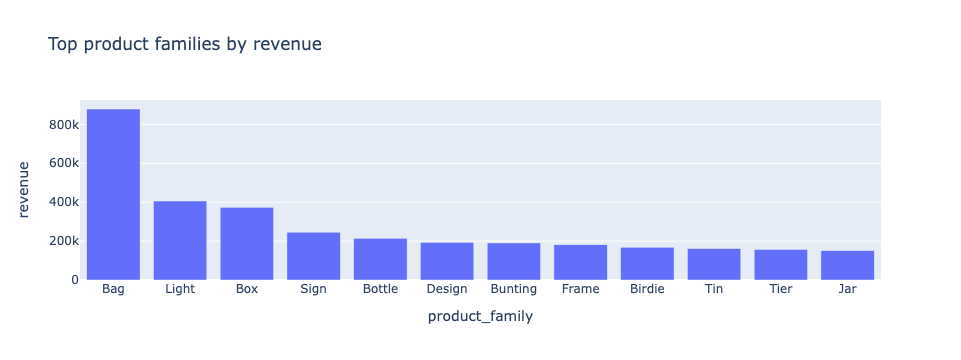

In [6]:
top_families = (
    transactions.groupby("product_family")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(12)
    .rename("revenue")
    .reset_index()
)
px.bar(top_families, x="product_family", y="revenue", title="Top product families by revenue")


## 2. Customer feature engineering

The segmentation and predictive modules use customer-level features built from transaction history:

- recency and tenure
- order, line, and unit frequency
- monetary value and basket depth
- product-family diversity
- repeat purchase behavior
- mean interpurchase time
- spend concentration across derived product families
- country concentration and seasonal concentration

These features are designed to reflect retail behavior rather than only generic machine learning convenience.


In [7]:
customer_features.describe(include="all").T.head(25)


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
customer_id,4338,4338,12346,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
first_purchase_date,4338,NaN,NaN,NaN,2011-04-30 17:06:50.857538048,2010-12-01 08:26:00,2011-01-17 11:13:15,2011-04-05 09:52:30,2011-08-19 10:11:30,2011-12-09 12:16:00,NaN
last_purchase_date,4338,NaN,NaN,NaN,2011-09-08 11:38:59.045643008,2010-12-01 09:53:00,2011-07-20 19:18:00,2011-10-20 10:40:30,2011-11-22 11:05:45,2011-12-09 12:50:00,NaN
unit_count,4338.0,NaN,NaN,NaN,1191.289073,1.0,160.0,379.0,992.75,196915.0,5046.081546
line_count,4338.0,NaN,NaN,NaN,91.720609,1.0,17.0,41.0,100.0,7847.0,228.785094
unique_product_count,4338.0,NaN,NaN,NaN,61.501153,1.0,16.0,35.0,77.0,1787.0,85.366768
spend_total,4338.0,NaN,NaN,NaN,2054.266602,3.75,307.414993,674.485016,1661.73999,280206.03125,8989.230469
mean_price,4338.0,NaN,NaN,NaN,4.467773,0.1225,2.203728,2.917611,3.829784,2033.099976,34.211449
category_diversity,4338.0,NaN,NaN,NaN,32.817658,1.0,11.0,23.0,44.0,488.0,33.085473
country_order_share,4338.0,NaN,NaN,NaN,0.999586,0.533333,1.0,1.0,1.0,1.0,0.011731


## 3. Customer segmentation

The first objective is to identify behaviorally distinct customer segments that can be interpreted in business terms. I compare KMeans and Gaussian Mixture variants across a small cluster range, then inspect the most interpretable solution.


In [8]:
segment_comparison = compare_segmentation_models(customer_features)
segment_comparison


,algorithm,n_clusters,silhouette,bic
0,gmm,3,0.363048,6675.555124
1,kmeans,5,0.290760,NaN
2,kmeans,4,0.286564,NaN
3,kmeans,3,0.278082,NaN
4,kmeans,6,0.248061,NaN
5,gmm,5,0.208643,-103267.672893
6,gmm,6,0.199902,-103593.742326
7,gmm,4,0.108617,-8184.841182


In [9]:
best_segment_row = segment_comparison.sort_values(["silhouette", "bic"], ascending=[False, True]).iloc[0]
segmentation = fit_segmentation_model(
    customer_features,
    algorithm=best_segment_row["algorithm"],
    n_clusters=int(best_segment_row["n_clusters"]),
)
segmentation.segment_summary


,segment_id,customers,recency_days,order_count,spend_total,avg_order_value,avg_basket_units,category_diversity,seasonal_concentration,repeat_purchase_rate,segment_name,share_of_customers
1,1,3902,57.0,2.0,588.534973,275.368347,151.000000,21.0,0.723166,0.500000,Low-Engagement Accounts,0.899493
0,0,434,11.0,13.0,5732.464844,484.732666,314.378788,60.5,0.312645,0.923077,Basket Builders,0.100046
2,2,2,163.5,1.5,122828.046875,80709.921875,57356.750000,1.5,0.999983,0.250000,Seasonal Buyers,0.000461


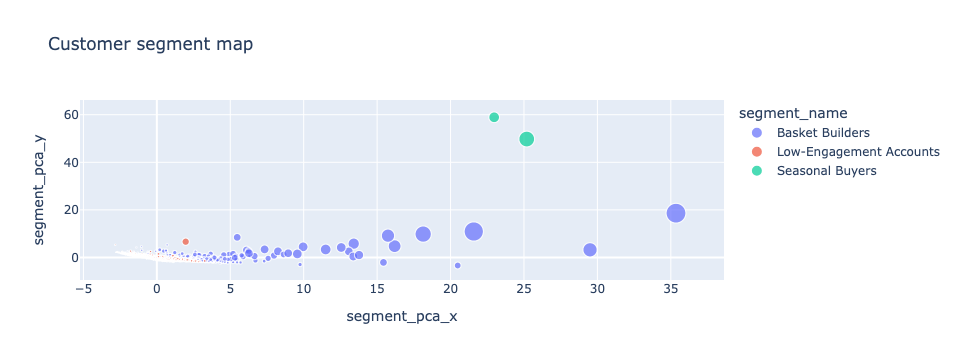

In [10]:
px.scatter(
    segmentation.customer_segments,
    x="segment_pca_x",
    y="segment_pca_y",
    color="segment_name",
    size="spend_total",
    hover_data=["customer_id", "order_count", "avg_order_value", "recency_days", "primary_country"],
    title="Customer segment map",
)


The segment labels are intentionally business-friendly rather than abstract cluster IDs. The useful output is not the cluster itself, but the fact that each segment implies a different action: protect loyal accounts, reactivate quieter buyers, or treat seasonal buyers with more precise timing.


## 4. Cohort and retention analysis

Cohort analysis reframes the customer base by first-purchase month. This highlights how quickly customers return after acquisition and whether some cohorts monetise more effectively over time.


In [11]:
retention_matrix = build_retention_matrix(cohort_retention)
retention_matrix.head()


cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12
cohort_month,,,,,,,,,,,,,
2010-12,1.0,0.366102,0.323164,0.384181,0.362712,0.397740,0.362712,0.349153,0.353672,0.395480,0.374011,0.502825,0.265537
2011-01,1.0,0.220624,0.266187,0.230216,0.321343,0.287770,0.247002,0.242206,0.299760,0.326139,0.364508,0.117506,NaN
2011-02,1.0,0.186842,0.186842,0.284211,0.271053,0.247368,0.252632,0.278947,0.247368,0.305263,0.068421,NaN,NaN
2011-03,1.0,0.150442,0.252212,0.199115,0.223451,0.168142,0.267699,0.230088,0.278761,0.086283,NaN,NaN,NaN
2011-04,1.0,0.213333,0.203333,0.210000,0.196667,0.226667,0.216667,0.260000,0.073333,NaN,NaN,NaN,NaN


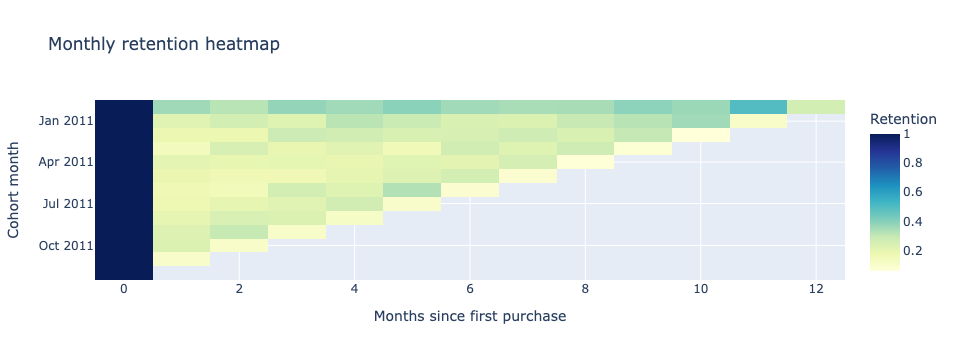

In [12]:
px.imshow(
    retention_matrix,
    aspect="auto",
    color_continuous_scale="YlGnBu",
    labels={"x": "Months since first purchase", "y": "Cohort month", "color": "Retention"},
    title="Monthly retention heatmap",
)


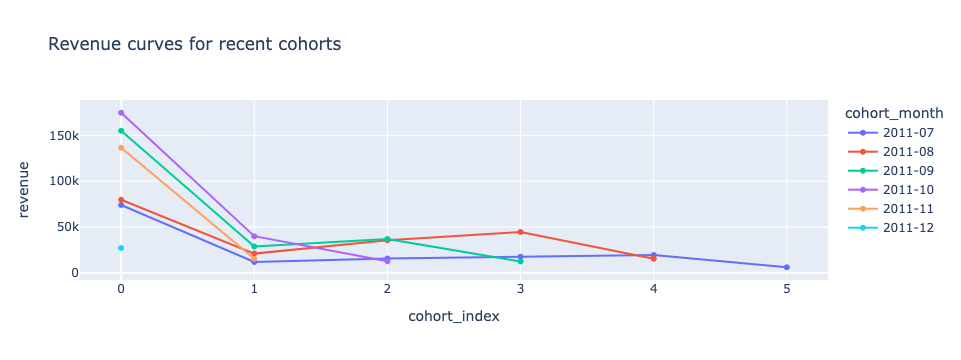

In [13]:
cohort_revenue["cohort_month"] = cohort_revenue["cohort_month"].astype(str)
selected_cohorts = cohort_revenue["cohort_month"].drop_duplicates().sort_values().tail(6)
px.line(
    cohort_revenue.loc[cohort_revenue["cohort_month"].isin(selected_cohorts)],
    x="cohort_index",
    y="revenue",
    color="cohort_month",
    markers=True,
    title="Revenue curves for recent cohorts",
)


## 5. Future customer value modeling

The platform uses rolling customer snapshots to inspect label density before choosing the primary target. When near-term spend is dense enough, the preferred target is 90-day future spend. If not, the pipeline falls back to 90-day repeat purchase propensity.


In [14]:
snapshots = build_snapshot_dataset(transactions)
target_choice = choose_target_definition(snapshots)
target_choice


{'task': 'regression',
 'target_column': 'future_spend_90d',
 'recommendation': 'Primary target: 90-day future spend. The dataset provides enough temporal coverage to frame customer value as a continuous near-term outcome while preserving a meaningful share of zeros.',
 'target_diagnostics': {'non_zero_spend_share': 0.5464030752333883,
  'repeat_share': 0.5464030752333883,
  'high_value_share': 0.10946366465312099}}

In [15]:
future_value = train_future_value_models(snapshots)
future_value.metrics


,model_name,rmse,mae,r2
1,hist_gbm,2381.734893,593.313187,0.689388
0,baseline,4343.982044,864.436523,-0.033253


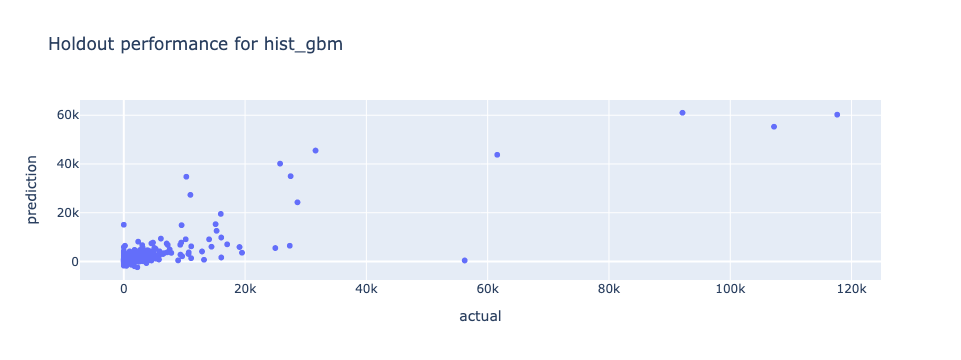

In [16]:
model_name = future_value.metrics.iloc[0]["model_name"]
pred_slice = future_value.predictions.loc[future_value.predictions["model_name"] == model_name]
plot_y = "score" if "score" in pred_slice.columns else "prediction"
px.scatter(
    pred_slice,
    x="actual",
    y=plot_y,
    title=f"Holdout performance for {model_name}",
)


## 6. Recommendation system

Recommendations are evaluated with a simple but instructive comparison:

- a popularity baseline that represents non-personalized merchandising
- a personalized item-item similarity recommender built from observed co-purchase patterns


In [17]:
recommender = train_recommender(transactions, product_lookup)
recommender.metrics


,model_name,precision_at_k,recall_at_k,hit_rate
0,item_similarity,0.0468,0.020770,0.284
1,popularity,0.0292,0.012122,0.228


In [18]:
example_customer = list(recommender.customer_history.keys())[0]
history_items = recommender.customer_history[example_customer][-10:]
popular_recs = recommend_popular(recommender.popularity_rank, history_items, 10)
personal_recs = recommend_personalized(
    customer_id=example_customer,
    customer_history=recommender.customer_history,
    item_similarity=recommender.item_similarity,
    item_index=recommender.item_index,
    popularity_rank=recommender.popularity_rank,
    product_lookup=product_lookup,
    n_items=10,
)

display(product_lookup.loc[product_lookup["product_id"].isin(history_items)])
display(popular_recs.head(10))
display(personal_recs.head(10))


,product_id,product_name,product_family
0,23166,MEDIUM CERAMIC TOP STORAGE JAR,Jar


,product_id,product_name,product_family,purchases,unique_customers
3414,85123A,WHITE HANGING HEART T-LIGHT HOLDER,Light,1796,797
1315,22423,REGENCY CAKESTAND 3 TIER,Tier,1546,828
3400,85099B,JUMBO BAG RED RETROSPOT,Bag,1416,583
2759,47566,PARTY BUNTING,Bunting,1321,689
3234,84879,ASSORTED COLOUR BIRD ORNAMENT,Ornament,1207,616
173,20725,LUNCH BAG RED RETROSPOT,Bag,1173,504
1603,22720,SET OF 3 CAKE TINS PANTRY DESIGN,Design,1044,611
430,21212,PACK OF 72 RETROSPOT CAKE CASES,Cases,964,601
176,20727,LUNCH BAG BLACK SKULL.,Bag,949,425
2253,23298,SPOTTY BUNTING,Bunting,919,539


,product_id,product_name,product_family,score
3635,23165,LARGE CERAMIC TOP STORAGE JAR,Jar,0.837054
3637,23167,SMALL CERAMIC TOP STORAGE JAR,Jar,0.704745
21724,47421,ASSORTED COLOUR LIZARD SUCTION HOOK,Hook,0.672933
8011,21927,BLUE/CREAM STRIPE CUSHION COVER,Cover,0.672335
2826,22755,SMALL PURPLE BABUSHKA NOTEBOOK,Notebook,0.671364
367626,84743C,ORANGE FELT VASE + FLOWERS,Flowers,0.669711
367472,84227,HEN HOUSE W CHICK IN NEST,Nest,0.669711
366958,21667,GLASS CAKE COVER AND PLATE,Plate,0.669711
368088,20964,POLYESTER FILLER PAD 60x40cm,Pad,0.669711
1931,21672,WHITE SPOT RED CERAMIC DRAWER KNOB,Knob,0.669194


## 7. Demand and trend insights

At the demand layer, the goal is not full-store forecasting. Instead, the analysis tracks which derived product families are rising or fading, how strongly demand varies over time, and whether the data supports a simple short-horizon demand view for leading product families.


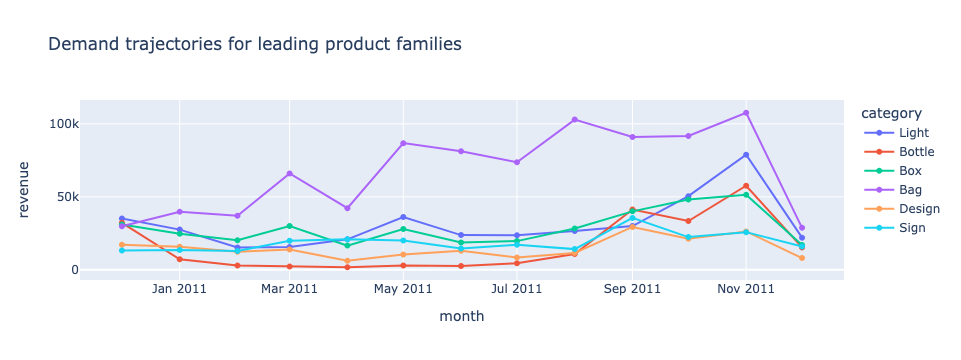

In [19]:
top_categories = monthly_demand.groupby("category")["revenue"].sum().sort_values(ascending=False).head(6).index
px.line(
    monthly_demand.loc[monthly_demand["category"].isin(top_categories)],
    x="month",
    y="revenue",
    color="category",
    markers=True,
    title="Demand trajectories for leading product families",
)


In [20]:
top_category_shifts(monthly_demand)


,category,latest_revenue,prior_revenue,absolute_change,pct_change
0,Birdie,168469.593750,0.000000,168469.593750,NaN
31,Unit,2135.699951,1152.599976,983.099976,0.852941
30,House,2186.699951,1302.300049,884.399902,0.679106
42,Clips,1582.849976,969.050049,613.799927,0.633404
65,Bucket,958.059998,415.440002,542.619995,1.306133
24,Tray,3026.359863,2513.849854,512.510010,0.203875
117,Pretty,585.789978,98.260002,487.529968,4.961632
62,Ladders,990.789978,532.299988,458.489990,0.861338
87,Strawbery,764.380005,548.250000,216.130005,0.394218
185,Sombrero,269.500000,54.600002,214.899994,3.935897


In [21]:
forecast_category = list(top_categories)[0]
forecast_category_demand(monthly_demand, forecast_category)


,month,category,forecast_revenue
0,2012-01-01,Bag,38728.919922
1,2012-02-01,Bag,36023.830078
2,2012-03-01,Bag,65010.447266


## 8. Final synthesis

The project now brings together customer structure, lifecycle dynamics, value prediction, personalization, and demand signals:

- Segmentation reveals whether revenue is concentrated in a loyal core or spread across emerging and seasonal buyers.
- Cohort analysis shows where post-acquisition drop-off is steepest and which cohorts preserve value over time.
- The future value model provides a prioritization layer for customer outreach.
- The recommender demonstrates the incremental value of tailoring assortments to purchase history.
- Demand analysis highlights which product families deserve closer monitoring during seasonal peaks or rapid trend shifts.


## Next steps

- Replace heuristic product-family derivation with a richer taxonomy if a cleaner product hierarchy becomes available.
- Add margin-aware prioritization so customer value and demand views reflect profitability, not revenue alone.
- Replace item similarity with an implicit factorization workflow for larger-scale personalization.
- Validate whether segment assignments remain stable over time or drift materially across calendar periods.
